<a href="https://colab.research.google.com/github/GrCOTE7/deep_learning_course/blob/gc7/01-01%20Introduction%20au%20Deep%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intro au Deep Learning (By Kevin Degila)

Ce code correspond à la vidéo #7 d'une [série de 160 épisodes](https://www.youtube.com/watch?v=XXyMPp_IwXg&list=PL049bGjkT7dIARLPrxvA4-tbEcg6k0UDX&index=7)

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD


In [2]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Scaling the data
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
data = s.fit_transform(data)
target = target.reshape((-1, 1))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=80718)


In [3]:
data.shape


(506, 13)

In [4]:
lr = Sequential([Dense(units=1, activation='relu')])
lr.compile(optimizer=SGD(learning_rate=0.1), loss='mae')
history = lr.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 22.0367 - val_loss: 20.6610
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.4384 - val_loss: 18.9679
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 18.6242 - val_loss: 17.2211
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 16.7531 - val_loss: 15.4856
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 15.0333 - val_loss: 13.9709
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 13.7044 - val_loss: 12.9987
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.8197 - val_loss: 12.0719
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.9670 - val_loss: 11.3917
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.3170 - val_loss: 10.7074
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 10.7332 - val_loss: 10.3376
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.3262 - val_loss: 9.9732
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step -

In [5]:
lr


<Sequential name=sequential, built=True>

# Premier Exemple d'apprentissage

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
data = pd.DataFrame([ {"n_chambres" : 2, "prix" : 10}, {"n_chambres" : 4, "prix" : 20}])
data


,n_chambres,prix
0,2,10
1,4,20


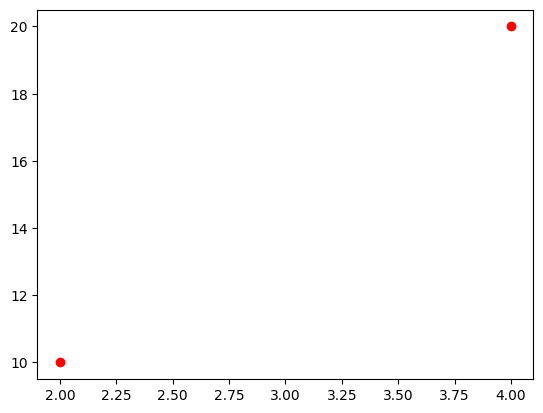

In [8]:
plt.scatter(data["n_chambres"], data['prix'], c="r")
plt.show()


prix = 5 * n_chambres

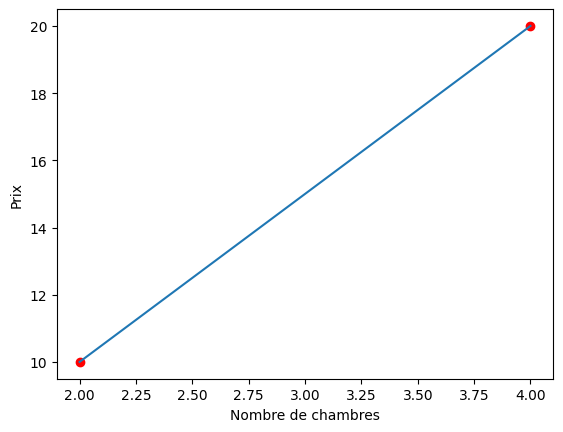

In [9]:
# y = 5 x

plt.scatter(data["n_chambres"], data['prix'], c="r")
plt.plot(data["n_chambres"], data['prix'])
plt.xlabel('Nombre de chambres')
plt.ylabel('Prix')
plt.show()


In [10]:
# entree  + instruction = sortie

# entree + sortie  == instruction ou les regles

# y= 5 x  model


In [11]:
data = pd.DataFrame([ {"n_chambres" : 2, "prix" : 10}, {"n_chambres" : 4, "prix" : 20},
                    {"n_chambres" : 3, "prix" : 15},
                     {"n_chambres" : 3, "prix" : 20},
                     {"n_chambres" : 1, "prix" : 3.5},
                    {"n_chambres" : 6, "prix" : 31},
                     {"n_chambres" : 5, "prix" : 33},
                    {"n_chambres" : 8, "prix" : 36},
                    {"n_chambres" : 7, "prix" : 50},
                    {"n_chambres" : 9, "prix" : 42},
                    ])
data


,n_chambres,prix
0,2,10.0
1,4,20.0
2,3,15.0
3,3,20.0
4,1,3.5
5,6,31.0
6,5,33.0
7,8,36.0
8,7,50.0
9,9,42.0


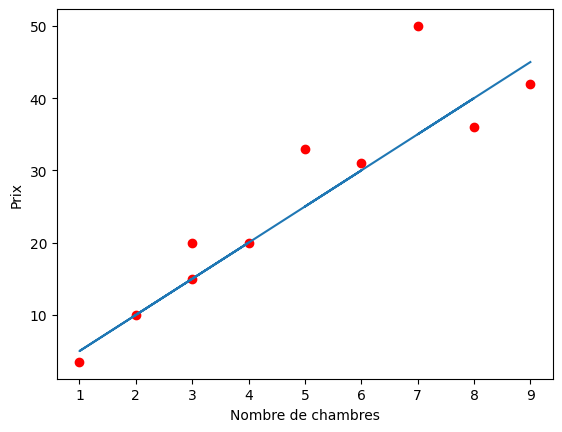

In [12]:
plt.scatter(data["n_chambres"], data['prix'], c="r")
plt.plot(data["n_chambres"], data['n_chambres'] * 5)
plt.xlabel('Nombre de chambres')
plt.ylabel('Prix')
plt.show()


In [13]:
# x = n_chambres
# y = Prix


In [14]:
def model(x, w):
  return w * x


In [15]:
model(x=3, w=5) # y= 5x


15

In [16]:
# y= 6x
model(x=3, w=6)


18

In [17]:
def erreur(x, w, y):
  y_model = model(x, w)

  distance = (y - y_model) **2

  return np.sum(distance)


In [18]:
# x = 6, y = 54

# y = 5x, w = 5



In [19]:
erreur(x=6, w=5, y=54)


np.int64(576)

In [20]:
# y_model = 5 * 6 = 30

distance = (54 - 30)**2


In [21]:
data['n_chambres'].values


array([2, 4, 3, 3, 1, 6, 5, 8, 7, 9])

In [22]:
n_chambres = data['n_chambres'].values
prix = data['prix'].values


In [23]:
erreur(x=n_chambres, w=5, y=prix) # y = 5 x


np.float64(342.25)

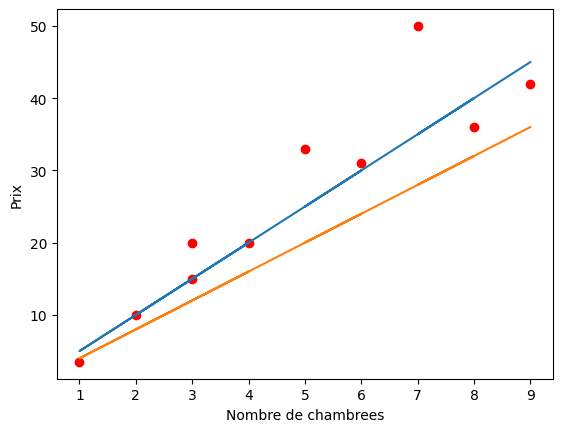

In [24]:
plt.scatter(data["n_chambres"], data['prix'], c="r")
plt.plot(data["n_chambres"], data['n_chambres'] * 5)
plt.plot(data["n_chambres"], data['n_chambres'] * 4)
plt.xlabel('Nombre de chambrees')
plt.ylabel('Prix')
plt.show()


In [25]:
erreur(x=n_chambres, w=4, y=prix)


np.float64(847.25)

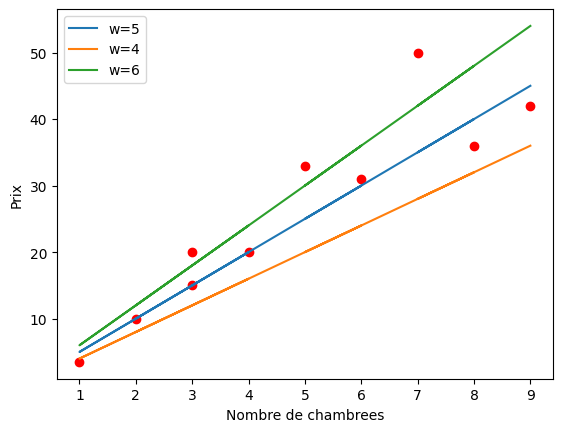

In [26]:
plt.scatter(data["n_chambres"], data['prix'], c="r")
plt.plot(data["n_chambres"], data['n_chambres'] * 5, label='w=5')
plt.plot(data["n_chambres"], data['n_chambres'] * 4, label='w=4')
plt.plot(data["n_chambres"], data['n_chambres'] * 6, label='w=6')
plt.xlabel('Nombre de chambrees')
plt.ylabel('Prix')
plt.legend()
plt.show()


In [27]:
erreur(x=n_chambres, w=6, y=prix)


np.float64(425.25)

In [28]:
erreur(x=n_chambres, w=4.9, y=prix)


np.float64(366.2899999999999)

In [29]:
f"w = 5 : {erreur(x=n_chambres, w=5.1, y=prix)}", f"w = 5.1 : {erreur(x=n_chambres, w=5, y=prix)}"


('w = 5 : 324.0900000000001', 'w = 5.1 : 342.25')

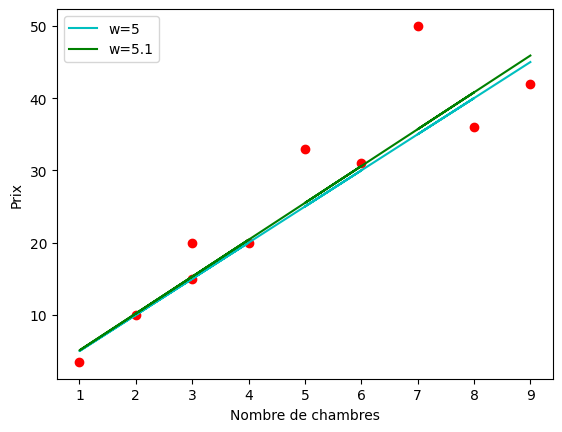

In [30]:
plt.scatter(data["n_chambres"], data['prix'], c="r")
plt.plot(data["n_chambres"], data['n_chambres'] * 5, c='c', label="w=5")
plt.plot(data["n_chambres"], data['n_chambres'] * 5.1, c='g', label="w=5.1")
plt.xlabel('Nombre de chambres')
plt.ylabel('Prix')
plt.legend()
plt.show()


In [31]:
erreur(x=n_chambres, w=5.2, y=prix) #y=5.2 x


np.float64(311.81000000000006)

In [32]:
erreur(x=n_chambres, w=5.3, y=prix)


np.float64(305.4099999999999)

In [33]:
erreur(x=n_chambres, w=5.4, y=prix) #y = 5.4x


np.float64(304.88999999999993)

In [34]:
erreur(x=n_chambres, w=5.5, y=prix)


np.float64(310.25)

In [35]:
erreur(x=n_chambres, w=5.6, y=prix)


np.float64(321.49)

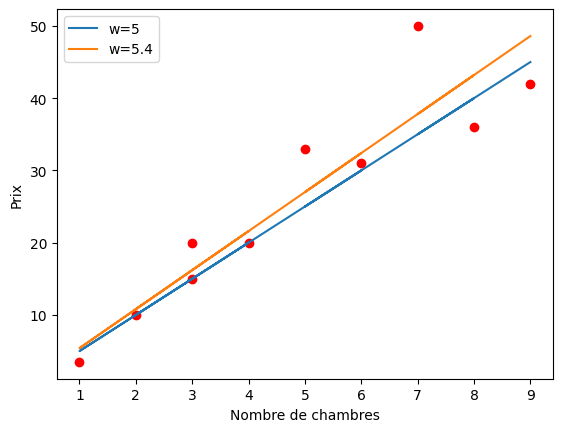

In [36]:
plt.scatter(data["n_chambres"], data['prix'], c="r")
plt.plot(data["n_chambres"], data['n_chambres'] * 5, label='w=5')
plt.plot(data["n_chambres"], data['n_chambres'] * 5.4, label='w=5.4')

plt.xlabel('Nombre de chambres')
plt.ylabel('Prix')
plt.legend()
plt.show()


In [37]:
possible_w = np.arange(-20, 20, 0.001)


In [38]:
possible_w


array([-20.   , -19.999, -19.998, ...,  19.997,  19.998,  19.999],
      shape=(40000,))

In [39]:
possible_w.size


40000

In [40]:
errors = []

for d in possible_w:
  e = erreur(x=n_chambres, w=d, y=prix)
  errors.append(e)


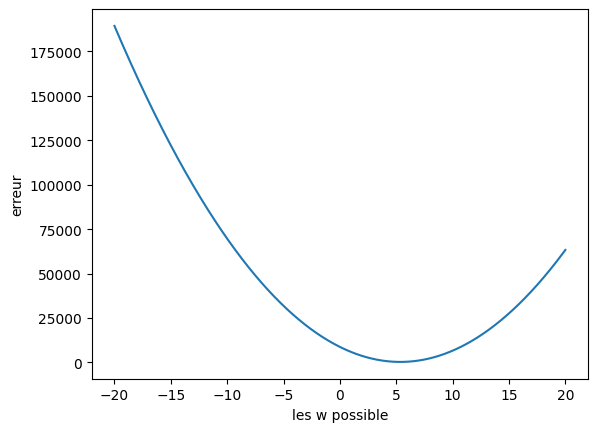

In [41]:
plt.plot(possible_w, errors)
plt.xlabel('les w possible')
plt.ylabel('erreur')
plt.show()


In [42]:
np.array(errors).min()


np.float64(304.3920140000027)

In [43]:
np.argmin(errors)


np.int64(25359)

In [44]:
possible_w[25359]


np.float64(5.359000000030992)

In [45]:
possible_w[np.argmin(errors)]


np.float64(5.359000000030992)

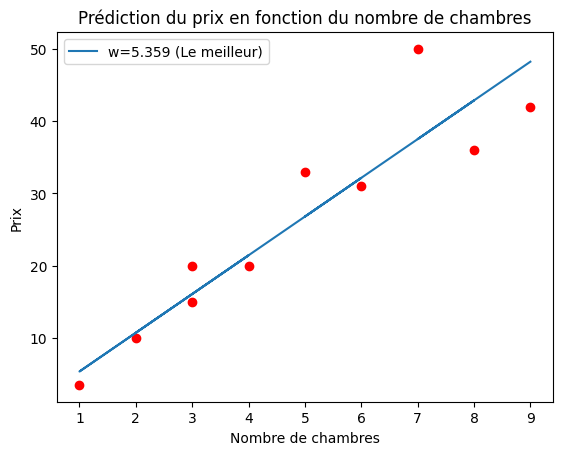

In [46]:
plt.scatter(data["n_chambres"], data['prix'], c="r")
plt.plot(data["n_chambres"], data['n_chambres'] * 5.359, label='w=5.359 (Le meilleur)')

plt.xlabel('Nombre de chambres')
plt.ylabel('Prix')
plt.legend()
plt.title('Prédiction du prix en fonction du nombre de chambres')
plt.show()


In [47]:
# Define the model
model_tf = Sequential([Dense(units=1, input_shape=[1])])

# Compile the model
model_tf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse')

# Display the model summary
model_tf.summary()


c:\Users\utilisateur\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Prepare data for TensorFlow
X = data['n_chambres'].values
y = data['prix'].values


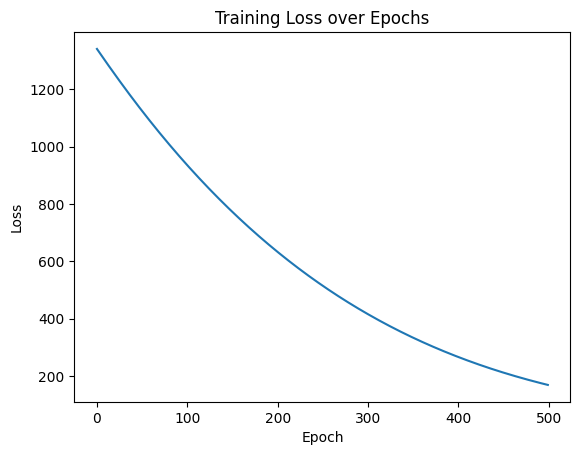

In [49]:
# Train the model
history_tf = model_tf.fit(X, y, epochs=500, verbose=0)

# Plot the training loss
plt.plot(history_tf.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.show()


In [50]:
# Make a prediction with the trained model
prediction = model_tf.predict(np.array([10]))
print(f"Prediction for 10 chambres: {prediction[0][0]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction for 10 chambres: 29.538211822509766
